<a href="https://colab.research.google.com/github/use-in/quant-lightgbm-backtester/blob/main/LightGBM%EA%B8%B0%EB%B0%98_%ED%80%80%ED%8A%B8_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 라이브러리 불러오기

!pip install yfinance lightgbm pandas numpy scikit-learn matplotlib -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit

In [2]:
# 2 . 데이터 수집

ticker = input("종목 티커를 입력해주세요: ").strip()

def get_valid_data(ticker):
    try:
        data = yf.download(ticker, start="2018-01-01", end="2024-01-01", progress=False)

        # 데이터가 없거나 100개 미만인 경우
        if data.empty or len(data) < 100:
            return None

        return data

    except Exception as e:
        print(f"데이터를 불러오는 중 오류가 발생했습니다: {e}")
        return None


data = get_valid_data(ticker)

if data is None:
  print("데이터가 없거나 너무 적어 프로그램을 종료합니다. ")
else:
  print(f"\n[{ticker}]에 대해 분석을 시작하겠습니다.")

# MultiIndex columns 단일화 처리
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

종목 티커를 입력해주세요: AAPL


/tmp/ipykernel_1692/2212901281.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01", end="2024-01-01", progress=False)



[AAPL]에 대해 분석을 시작하겠습니다.


In [3]:
# 3. 피처 엔지니어링

# (1) 이동평균선 및 비율 피처
df['SMA_10'] = df['Close'].rolling(10).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()
df['SMA_Ratio'] = df['SMA_10'] / df['SMA_50']

# (2) RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df['RSI'] = 100 - (100 / (1 + rs))

# (3) MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# (4) 일일 수익률 및 변동성
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(20).std()

# (5) Target: 내일 주가 상승시 1, 하락/보합시 0
df['Target'] = np.where(df['Return'].shift(-1) > 0, 1, 0)

# 결측치 제거
df.dropna(inplace=True)

# 모델에 입력할 피처 정의
features = ['SMA_Ratio', 'RSI', 'MACD', 'MACD_Signal', 'Volatility', 'Return']
X = df[features]
y = df['Target']

In [4]:
# 4. 시계열 검증

# 5개의 시계열 검증 구간 생성 (미래 데이터 누수 방지)
tscv = TimeSeriesSplit(n_splits=5)
df['Signal'] = 0  # 모델 매매 예측 신호를 저장할 컬럼

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=3,         # 트리의 최대 깊이 제한
        num_leaves=7,        # 리프 노드 수 제한
        random_state=42,
        verbose=-1
    )

    # 과거 데이터로 모델 학습 후 검증 구간 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # 예측된 신호 저장 (1: 매수, 0: 관망)
    df.iloc[test_idx, df.columns.get_loc('Signal')] = preds

In [5]:
# 5. 백테스팅 및 리스크 지표 산출

# 시계열 검증이 이루어진 테스트 구간만 백테스팅 대상으로 추출
first_test_idx = list(tscv.split(X))[0][1][0]
eval_df = df.iloc[first_test_idx:].copy()

# 오늘 예측한 신호로 내일 주가 변화율을 누림
eval_df['Position'] = eval_df['Signal'].shift(1)
eval_df['Strategy_Return'] = eval_df['Return'] * eval_df['Position']

# 누적 수익률 계산
eval_df['Cum_Market'] = (1 + eval_df['Return']).cumprod()
eval_df['Cum_Strategy'] = (1 + eval_df['Strategy_Return']).cumprod()

# (1) CAGR
days = (eval_df.index[-1] - eval_df.index[0]).days
cagr_strategy = (eval_df['Cum_Strategy'].iloc[-1]) ** (365 / days) - 1
cagr_market = (eval_df['Cum_Market'].iloc[-1]) ** (365 / days) - 1

# (2) MDD
peak = eval_df['Cum_Strategy'].cummax()
drawdown = (eval_df['Cum_Strategy'] - peak) / peak
mdd = drawdown.min()

# (3) Sharpe Ratio
sharpe = (eval_df['Strategy_Return'].mean() / (eval_df['Strategy_Return'].std() + 1e-9)) * np.sqrt(252)

 백테스팅 결과 분석 (AAPL)
 전략 연평균 수익률 (CAGR) : 26.42%
 단순 보유 연평균 수익률    : 36.95%
 전략 최대 낙폭 (MDD)       : -30.56%
 샤프 지수 (Sharpe Ratio)   : 1.03


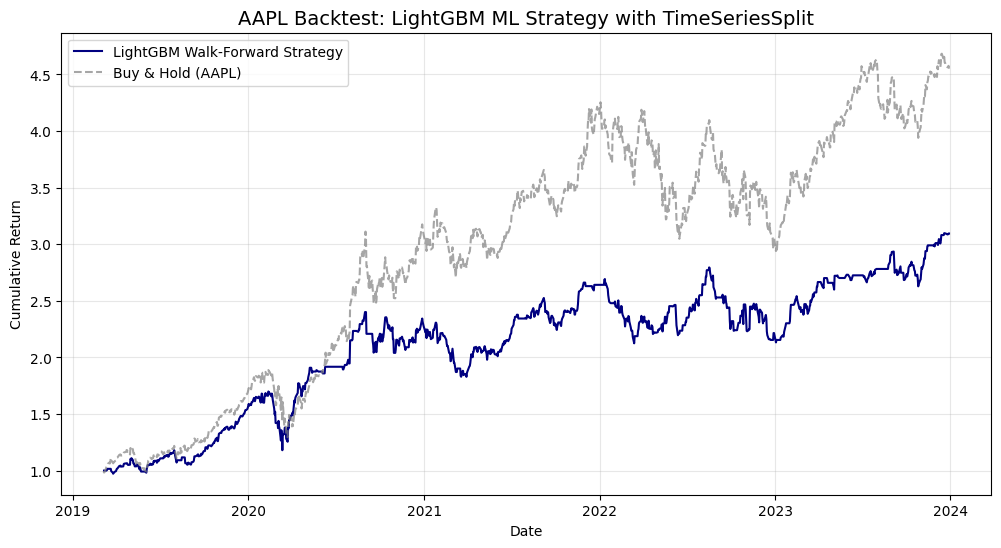

In [6]:
# 6. 결과 출력 및 시각화

print(f" 백테스팅 결과 분석 ({ticker})")
print(f" 전략 연평균 수익률 (CAGR) : {cagr_strategy:.2%}")
print(f" 단순 보유 연평균 수익률    : {cagr_market:.2%}")
print(f" 전략 최대 낙폭 (MDD)       : {mdd:.2%}")
print(f" 샤프 지수 (Sharpe Ratio)   : {sharpe:.2f}")

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(eval_df['Cum_Strategy'], label='LightGBM Walk-Forward Strategy', color='navy', linewidth=1.5)
plt.plot(eval_df['Cum_Market'], label=f'Buy & Hold ({ticker})', color='gray', linestyle='--', alpha=0.7)
plt.title(f'{ticker} Backtest: LightGBM ML Strategy with TimeSeriesSplit', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()